# Inventory Monitoring at Distribution Centers
**TODO**: Give a helpful introduction to what this notebook is for. Remember that comments, explanations and good documentation make your project informative and professional.

**Note:** This notebook has a bunch of code and markdown cells with TODOs that you have to complete. These are meant to be helpful guidelines for you to finish your project while meeting the requirements in the project rubrics. Feel free to change the order of the TODO's and/or use more than one cell to complete all the tasks.

In [4]:
!pip install tqdm

In [5]:
!pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


In [6]:
import pandas as pd
from tqdm import tqdm
import seaborn as sns
from PIL import Image
import sagemaker
import boto3
import os 
from os import listdir
from os.path import isdir, isfile, join
from sklearn.model_selection import train_test_split
import shutil

In [7]:
import torchvision
print(torchvision.__version__)
print(sagemaker.__version__)

0.19.1a0+5ed21bd
2.227.0


## Data Preparation
**TODO:** Run the cell below to download the data.

The cell below creates a folder called `train_data`, downloads training data and arranges it in subfolders. Each of these subfolders contain images where the number of objects is equal to the name of the folder. For instance, all images in folder `1` has images with 1 object in them. Images are not divided into training, testing or validation sets. If you feel like the number of samples are not enough, you can always download more data (instructions for that can be found [here](https://registry.opendata.aws/amazon-bin-imagery/)). However, we are not acessing you on the accuracy of your final trained model, but how you create your machine learning engineering pipeline.

In [51]:
import os
import json
import boto3

source_data_root = "./source_data"

def download_and_arrange_data():
    s3_client = boto3.client('s3')

    with open('file_list.json', 'r') as f:
        d=json.load(f)

    for k, v in d.items():
        print(f"Downloading Images with {k} objects")
        directory=os.path.join(source_data_root, k)
        if not os.path.exists(directory):
            os.makedirs(directory)
        for file_path in tqdm(v):
            file_name=os.path.basename(file_path).split('.')[0]+'.jpg'
            s3_client.download_file('aft-vbi-pds', os.path.join('bin-images', file_name),
                             os.path.join(directory, file_name))


In [52]:
download_and_arrange_data()

100%|██████████| 1228/1228 [01:29<00:00, 13.69it/s]


100%|██████████| 2299/2299 [02:48<00:00, 13.65it/s]


100%|██████████| 2666/2666 [03:21<00:00, 13.22it/s]


100%|██████████| 2373/2373 [02:52<00:00, 13.77it/s]


100%|██████████| 1875/1875 [02:13<00:00, 14.03it/s]


## Dataset
**TODO:** Explain what dataset you are using for this project. Give a small overview of the classes, class distributions etc that can help anyone not familiar with the dataset get a better understanding of it. You can find more information about the data [here](https://registry.opendata.aws/amazon-bin-imagery/).

In [53]:
from os import listdir
from os.path import isdir, isfile, join

count_of_pictures_by_class = []

classes_root = [join(source_data_root, entry) for entry in listdir(source_data_root) if isdir(join(source_data_root, entry))]

for class_root in classes_root:
    image_count = len([entry for entry in listdir(class_root) if isfile(join(class_root,entry))])
    count_of_pictures_by_class.append([class_root.split('/')[-1], image_count])

df = pd.DataFrame(count_of_pictures_by_class, columns=['ObjectsInImageCount', 'ImageCount'])
df.head()

,ObjectsInImageCount,ImageCount
0,1,1228
1,2,2299
2,3,2666
3,4,2373
4,5,1875


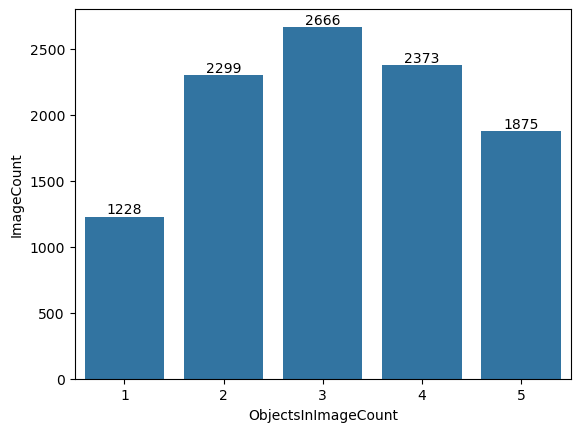

In [54]:
ax = sns.barplot(data=df, x='ObjectsInImageCount', y='ImageCount')
ax.bar_label(ax.containers[0], fontsize=10);

In [56]:
im = Image.open('source_data/1/00014.jpg')
print(im.size)

(526, 313)


In [59]:
#TODO: Perform any data cleaning or data preprocessing

test_data_root = "./test_data"
train_data_root = "./train_data"

for class_root in classes_root:
    file_names = [entry for entry in listdir(class_root) if isfile(join(class_root,entry))]
    class_name = os.path.basename(class_root)
    x_train, x_test = train_test_split(file_names, test_size=0.2, random_state=42)
    print("{} for class {} have been split into {} images for train and {} images for test".format(len(file_names), class_name, len(x_train), len(x_test)))

    directory=os.path.join(test_data_root, class_name)
    if not os.path.exists(directory):
        os.makedirs(directory)
        
    for filename in x_test:
        src = os.path.join(class_root, filename)
        dst = os.path.join(test_data_root, class_name, filename)
        shutil.copy2(os.path.join(class_root, filename), os.path.join(test_data_root, class_name, filename))

    directory=os.path.join(train_data_root, class_name)
    if not os.path.exists(directory):
        os.makedirs(directory)
        
    for filename in x_train:
        src = os.path.join(class_root, filename)
        dst = os.path.join(train_data_root, class_name, filename)
        shutil.copy2(os.path.join(class_root, filename), os.path.join(train_data_root, class_name, filename))


1228 for class 1 have been split into 982 images for train and 246 images for test
2299 for class 2 have been split into 1839 images for train and 460 images for test
2666 for class 3 have been split into 2132 images for train and 534 images for test
2373 for class 4 have been split into 1898 images for train and 475 images for test
1875 for class 5 have been split into 1500 images for train and 375 images for test


In [8]:
from sagemaker import get_execution_role
session = sagemaker.Session()

bucket= 'svme-sagemaker-udacity-d123dwe2d'
print("Default Bucket: {}".format(bucket))
os.environ["DEFAULT_S3_BUCKET"] = bucket

region = 'eu-central-1'
print("AWS Region: {}".format(region))

role = get_execution_role()
print("Role: {}".format(role))

Default Bucket: svme-sagemaker-udacity-d123dwe2d
AWS Region: eu-central-1
Role: arn:aws:iam::730834456607:role/service-role/AmazonSageMaker-ExecutionRole-20241122T080595


In [61]:
#TODO: Upload the data to AWS S3

In [63]:
!aws s3 sync --quiet ./train_data/ s3://${DEFAULT_S3_BUCKET}/train_data/
!aws s3 sync --quiet ./test_data/ s3://${DEFAULT_S3_BUCKET}/test_data/

## Model Training
**TODO:** This is the part where you can train a model. The type or architecture of the model you use is not important. 

**Note:** You will need to use the `train.py` script to train your model.

In [17]:
#TODO: Declare your model training hyperparameter.
#NOTE: You do not need to do hyperparameter tuning. You can use fixed hyperparameter values
hyperparameters = {
    'batch-size': 32,
    'epochs': 1,
    'lr': 0.0016
}

In [18]:
#TODO: Create your training estimator
from sagemaker.pytorch import PyTorch

estimator = PyTorch(
    entry_point='train-v1.py', 
    role=role, 
    py_version='py36',
    framework_version='1.6',
    instance_count=1, 
    instance_type='ml.m5.2xlarge',
    hyperparameters = hyperparameters,
)


In [19]:
# TODO: Fit your estimator
inputs = {
    'train': f's3://{bucket}/train_data', # available as SM_CHANNEL_TRAIN in script
    'test': f's3://{bucket}/test_data' # available as SM_CHANNEL_TEST in script
}

estimator.fit(inputs=inputs, wait=False)

INFO:sagemaker.image_uris:image_uri is not presented, retrieving image_uri based on instance_type, framework etc.
INFO:sagemaker.image_uris:image_uri is not presented, retrieving image_uri based on instance_type, framework etc.
INFO:sagemaker:Creating training-job with name: pytorch-training-2025-03-03-12-40-02-823


### Refinment

In [20]:
from sagemaker.pytorch import PyTorch

hyperparameters = {
    'batch-size': 32,
    'epochs': 2,
    'lr': 0.0016,
    'k-folds': 5
}

estimator_v2 = PyTorch(
    entry_point='train-v2.py', 
    role=role, 
    py_version='py36',
    framework_version='1.6',
    instance_count=1, 
    instance_type='ml.m5.2xlarge',
    hyperparameters = hyperparameters,
)

inputs = {
    'train': f's3://{bucket}/train_data', # available as SM_CHANNEL_TRAIN in script
    'test': f's3://{bucket}/test_data' # available as SM_CHANNEL_TEST in script
}

estimator_v2.fit(inputs=inputs, wait=False)

INFO:sagemaker.image_uris:image_uri is not presented, retrieving image_uri based on instance_type, framework etc.
INFO:sagemaker.image_uris:image_uri is not presented, retrieving image_uri based on instance_type, framework etc.
INFO:sagemaker:Creating training-job with name: pytorch-training-2025-03-03-13-06-12-385


## Standout Suggestions
You do not need to perform the tasks below to finish your project. However, you can attempt these tasks to turn your project into a more advanced portfolio piece.

### Hyperparameter Tuning
**TODO:** Here you can perform hyperparameter tuning to increase the performance of your model. You are encouraged to 
- tune as many hyperparameters as you can to get the best performance from your model
- explain why you chose to tune those particular hyperparameters and the ranges.


In [25]:
#TODO: Create your hyperparameter search space
from sagemaker.tuner import (
    IntegerParameter,
    CategoricalParameter,
    ContinuousParameter, 
    HyperparameterTuner
)

hyperparameter_ranges = {
    'lr': ContinuousParameter(0.001,0.01),
    'batch-size': CategoricalParameter([16, 32, 48])
}

In [26]:
#TODO: Create your training estimator
estimator_v3 = PyTorch(
    entry_point='train-v3.py', 
    role=role, 
    py_version='py36',
    framework_version='1.6',
    instance_count=1, 
    instance_type='ml.m5.2xlarge'
)

objective_metric_name = "accuracy"
objective_type = "Maximize"
metric_definitions = [{"Name": "accuracy", "Regex": "Test: Accuracy: ([0-9\\.]+)"}]

tuner = HyperparameterTuner(
    estimator_v3,
    objective_metric_name, 
    hyperparameter_ranges, 
    metric_definitions, 
    max_jobs=4,
    max_parallel_jobs=1, 
    objective_type=objective_type
)

In [27]:
# TODO: Fit your estimator
inputs = {
    'train': f's3://{bucket}/train_data', # available as SM_CHANNEL_TRAIN in script
    'test': f's3://{bucket}/test_data' # available as SM_CHANNEL_TEST in script
}

tuner.fit(inputs=inputs, wait=False)

INFO:sagemaker.image_uris:image_uri is not presented, retrieving image_uri based on instance_type, framework etc.
INFO:sagemaker.image_uris:image_uri is not presented, retrieving image_uri based on instance_type, framework etc.
INFO:sagemaker.image_uris:image_uri is not presented, retrieving image_uri based on instance_type, framework etc.
INFO:sagemaker:Creating hyperparameter tuning job with name: pytorch-training-250303-1401


In [ ]:
# TODO: Find the best hyperparameters

### Model Profiling and Debugging
**TODO:** Use model debugging and profiling to better monitor and debug your model training job.

In [ ]:
# TODO: Set up debugging and profiling rules and hooks

In [ ]:
# TODO: Create and fit an estimator

In [ ]:
# TODO: Plot a debugging output.

**TODO**: Is there some anomalous behaviour in your debugging output? If so, what is the error and how will you fix it?  
**TODO**: If not, suppose there was an error. What would that error look like and how would you have fixed it?

In [ ]:
# TODO: Display the profiler output

### Model Deploying and Querying
**TODO:** Can you deploy your model to an endpoint and then query that endpoint to get a result?

In [ ]:
# TODO: Deploy your model to an endpoint

In [ ]:
# TODO: Run an prediction on the endpoint

In [ ]:
# TODO: Remember to shutdown/delete your endpoint once your work is done

### Cheaper Training and Cost Analysis
**TODO:** Can you perform a cost analysis of your system and then use spot instances to lessen your model training cost?

In [ ]:
# TODO: Cost Analysis

In [ ]:
# TODO: Train your model using a spot instance

### Multi-Instance Training
**TODO:** Can you train your model on multiple instances?

In [ ]:
# TODO: Train your model on Multiple Instances